# Fitting a continuum to real data

This notebook applies `splinenorm` to an observed M-dwarf spectrum (TRAPPIST-1, epoch 59065, echelle order 46).
It assumes familiarity with the basic workflow in [`getting_started.ipynb`](getting_started.ipynb).

We compare **two ways** to account for the continuum when comparing data to a PHOENIX model:

| | Reference spectrum | Strategy |
|---|---|---|
| **A** | flat line (`ones`) | Fit and divide the continuum of data and model **separately** |
| **B** | PHOENIX template | Fit data **directly** with a spline-modulated PHOENIX forward model |

Both approaches handle non-finite edge pixels before calling `solve_linear`.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from splinenorm.functions import solve_linear
from splinenorm.spline_model import SplineModel

%matplotlib inline

In [11]:
# Observed spectrum
data_file = Path("../data/mdwarf_order46_epoch59065.txt")
wavelength, flux, err = np.loadtxt(data_file, unpack=True, comments="#")

# PHOENIX model resampled to the same wavelength grid
phoenix_file = Path("../data/lte02500-5.00-0.0.PHOENIX-NewEra-ACES-COND-2023.HSR_SPIROU.txt")
phoenix_flux = np.loadtxt(phoenix_file, comments="#")[:, 1]
phoenix_flux /= np.median(phoenix_flux)

good = np.isfinite(flux) & np.isfinite(err) & np.isfinite(wavelength) & (err > 0)
flux_for_fit = np.interp(wavelength, wavelength[good], flux[good])
err_floor = np.median(err[good])
err_for_fit = np.where(good, err, err_floor * 10.0)
inv_var = err_for_fit**-2

print(f"Usable pixels: {good.sum()} / {wavelength.size}")

Usable pixels: 3962 / 4088


## A. Separate continuum normalization (flat reference)

Build spline components from a flat reference and fit the continuum of the **data** and the **PHOENIX model** independently. Compare the two continuum-normalized spectra.

In [12]:
n_knots = 15
spline_flat = SplineModel(n_knots=n_knots)(np.ones_like(wavelength))

continuum_data = solve_linear(flux_for_fit, inv_var, spline_flat) @ spline_flat
continuum_phoenix = solve_linear(phoenix_flux, np.ones_like(phoenix_flux), spline_flat) @ spline_flat

norm_data_a = np.where(good, flux / continuum_data, np.nan)
norm_phoenix_a = phoenix_flux / continuum_phoenix
residual_a = norm_data_a[good] - norm_phoenix_a[good]

## B. PHOENIX forward model (spline decomposition)

Build spline components that **modulate the PHOENIX template** and fit their amplitudes directly to the observed flux. The result is a single forward model, $\sum_j \phi_j\, B_j(\lambda)\, F_\mathrm{PHOENIX}(\lambda)$.

In [13]:
spline_phoenix = SplineModel(n_knots=n_knots)(phoenix_flux)
forward_model = solve_linear(flux_for_fit, inv_var, spline_phoenix) @ spline_phoenix
residual_b = flux[good] - forward_model[good]

## Compare residuals

- **A**: difference between independently normalized data and PHOENIX spectra.
- **B**: data minus the PHOENIX forward model (continuum and template fitted jointly).

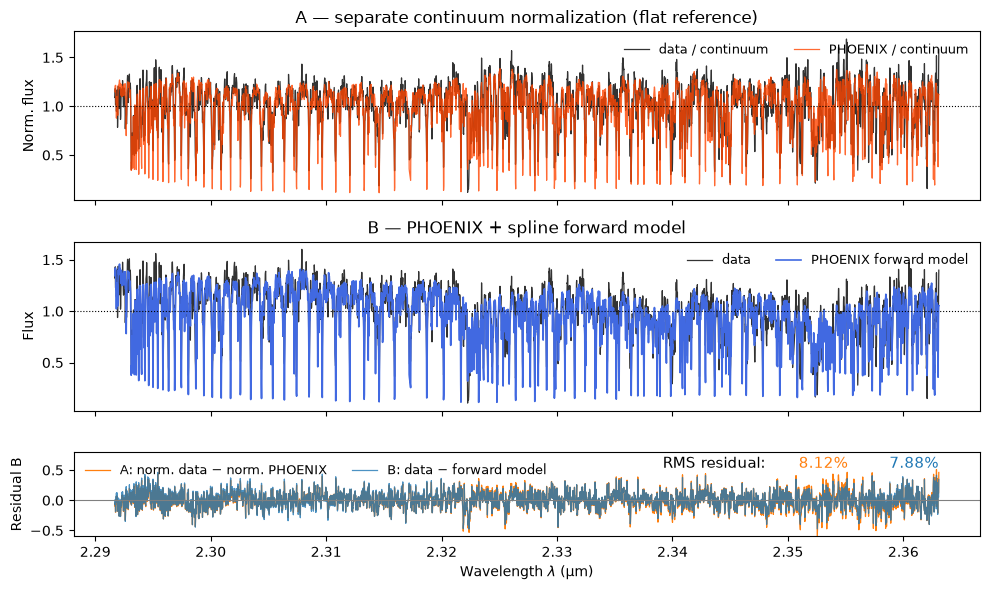

RMS residual A: 0.1345
RMS residual B: 0.1277


In [28]:
lw = 0.9
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 2, 1]})

# A: separate normalization
axes[0].plot(wavelength, norm_data_a, color="k", lw=lw, alpha=0.8, label="data / continuum")
axes[0].plot(wavelength, norm_phoenix_a, color="orangered", lw=lw, alpha=0.8, label="PHOENIX / continuum")
axes[0].axhline(1.0, color="k", ls=":", lw=0.8)
axes[0].set_ylabel("Norm. flux")
axes[0].legend(ncol=2, loc="upper right", frameon=False, fontsize=9)
axes[0].set_title("A — separate continuum normalization (flat reference)")

# B: forward model with pixel validity overlay
ax_b = axes[1]
ax_b.fill_between(
    wavelength, 0, 1, where=good, alpha=0.12, color="tab:green",
    transform=ax_b.get_xaxis_transform(), label="used in fit",
)
ax_b.fill_between(
    wavelength, 0, 1, where=~good, alpha=0.20, color="tab:red",
    transform=ax_b.get_xaxis_transform(), label="interpolated / downweighted",
)
ax_b.plot(wavelength[good], flux[good], color="k", lw=lw, alpha=0.8, label="data")
ax_b.plot(wavelength, forward_model, color="royalblue", lw=1.2, label="PHOENIX forward model")
ax_b.axhline(1.0, color="k", ls=":", lw=0.8)
ax_b.set_ylabel("Flux")
ax_b.legend(ncol=2, loc="upper right", frameon=False, fontsize=9)
ax_b.set_title("B — PHOENIX + spline forward model")

# Residuals
scatter_a = np.median(np.abs(residual_a))
scatter_b = np.median(np.abs(residual_b))
axes[2].plot(wavelength[good], residual_a, color="tab:orange", lw=lw, label="A: norm. data − norm. PHOENIX")
axes[2].plot(wavelength[good], residual_b, color="tab:blue", lw=lw, label="B: data − forward model", alpha=0.8)
axes[2].axhline(0, color="gray", ls="-", lw=0.8)

axes[2].text(0.65, 0.95, "RMS residual:",
             transform=axes[2].transAxes, ha="left", va="top", fontsize=11)
axes[2].text(0.80, 0.95, f"{scatter_a:.2%}",
             transform=axes[2].transAxes, ha="left", va="top", fontsize=11, color="tab:orange")
axes[2].text(0.90, 0.95, f"{scatter_b:.2%}",
             transform=axes[2].transAxes, ha="left", va="top", fontsize=11, color="tab:blue")

axes[2].set_xlabel(r"Wavelength $\lambda$ (µm)")
axes[2].set_ylabel("Residual")
axes[2].legend(ncol=2, loc="upper left", frameon=False, fontsize=9)
axes[2].set_ylim(-0.6, 0.8)

fig.tight_layout()
fig.savefig("fit_continuum_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"RMS residual A: {np.sqrt(np.mean(residual_a**2)):.4f}")
print(f"RMS residual B: {np.sqrt(np.mean(residual_b**2)):.4f}")

## RMS vs. number of knots

How sensitive are the two approaches to the spline flexibility? Below we sweep `n_knots` from 5 to 50 and track the RMS residual at valid pixels.

Choosing `n_knots` is a trade-off between the flexibility of the spline and the number of parameters. This value will be different for different datasets. The resolving power of the instrument, the signal-to-noise ratio, and the spectral features present will all play a role. Datasets with broad lines (e.g. fast rotators or moderate-resolution spectra) should try to *minimize the number of knots* to avoid fitting "real" atmospheric features with the continuum. In those cases, opting for a traditional pre-normalization routine (approach A) is recommended.

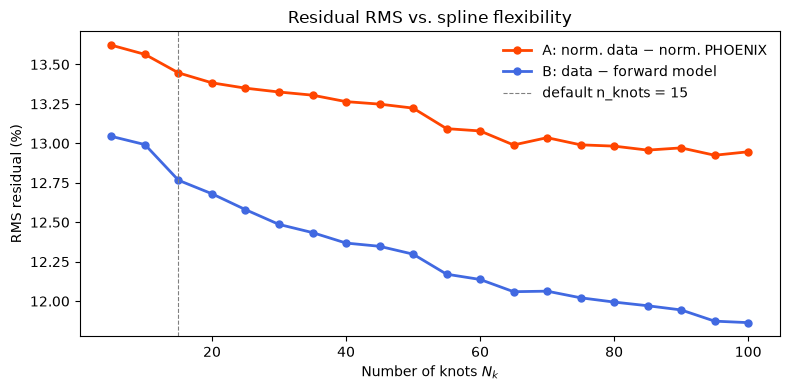

In [34]:
# RMS as a function of N_knots
knot_counts = np.arange(5, 101, 5)
rms_a = np.empty(knot_counts.size)
rms_b = np.empty(knot_counts.size)

for i, n_k in enumerate(knot_counts):
    spline_flat = SplineModel(n_knots=n_k)(np.ones_like(wavelength))
    continuum_data = solve_linear(flux_for_fit, inv_var, spline_flat) @ spline_flat
    continuum_phoenix = solve_linear(phoenix_flux, np.ones_like(phoenix_flux), spline_flat) @ spline_flat
    residual_a_k = (flux[good] / continuum_data[good]) - (phoenix_flux[good] / continuum_phoenix[good])
    rms_a[i] = np.sqrt(np.mean(residual_a_k**2))

    spline_phoenix = SplineModel(n_knots=n_k)(phoenix_flux)
    forward_model_k = solve_linear(flux_for_fit, inv_var, spline_phoenix) @ spline_phoenix
    residual_b_k = flux[good] - forward_model_k[good]
    rms_b[i] = np.sqrt(np.mean(residual_b_k**2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(knot_counts, rms_a * 100, "o-", ms=5, lw=2, color="orangered", label="A: norm. data − norm. PHOENIX")
ax.plot(knot_counts, rms_b * 100, "o-", ms=5, lw=2, color="royalblue", label="B: data − forward model")
ax.axvline(n_knots, color="gray", ls="--", lw=0.8, label=f"default n_knots = {n_knots}")
ax.set_xlabel(r"Number of knots $N_k$")
ax.set_ylabel("RMS residual (%)")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Residual RMS vs. spline flexibility")
fig.tight_layout()
fig.savefig("fit_continuum_rms_vs_knots.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary

- **Approach A** is useful when you only need a continuum-normalized spectrum and will compare data and models afterward.
- **Approach B** forward-models the data with a PHOENIX template modulated by splines, coupling continuum and model shape in a single fit.
- Non-finite edge pixels are interpolated in flux and downweighted in error before both fits.
- Residual RMS is only weakly sensitive to `n_knots` in this example; very few knots already capture the smooth blaze envelope.
- For a synthetic injection–recovery test, see [`getting_started.ipynb`](getting_started.ipynb).
